<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [2]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  2.97MB/s    in 53s     

2026-09-29 13:10:51 (2.86 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data


In [4]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



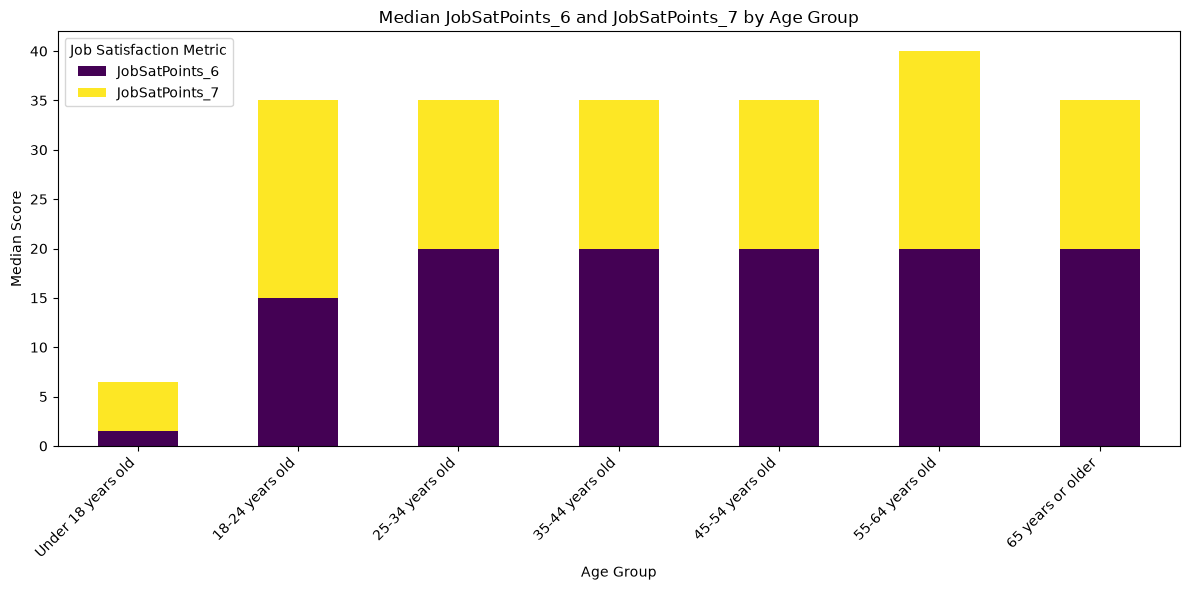

In [6]:
# Create a working dataframe
plot_df = df[["Age", "JobSatPoints_6", "JobSatPoints_7"]].copy()

# Convert satisfaction scores to numeric
plot_df["JobSatPoints_6"] = pd.to_numeric(
    plot_df["JobSatPoints_6"], errors="coerce"
)

plot_df["JobSatPoints_7"] = pd.to_numeric(
    plot_df["JobSatPoints_7"], errors="coerce"
)

# Remove rows with missing values
plot_df = plot_df.dropna(
    subset=["Age", "JobSatPoints_6", "JobSatPoints_7"]
)

# Calculate median scores by age group
median_scores = (
    plot_df.groupby("Age")[
    ["JobSatPoints_6", "JobSatPoints_7"]
    ]
    .median()
)

# Order age groups logically
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

median_scores = median_scores.reindex(age_order)

# Create stacked bar chart
ax = median_scores.plot(
kind="bar",
stacked=True,
figsize=(12, 6),
colormap="viridis"
)

plt.title(
    "Median JobSatPoints_6 and JobSatPoints_7 by Age Group"
)
plt.xlabel("Age Group")
plt.ylabel("Median Score")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Job Satisfaction Metric"
)
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


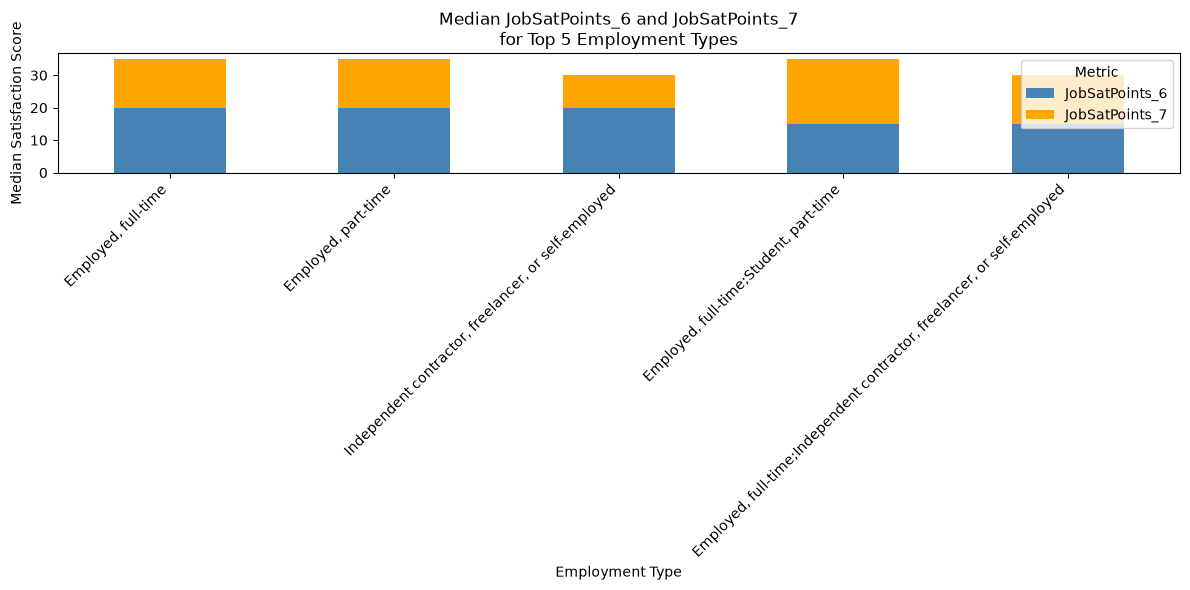

In [7]:
# Create working dataframe
plot_df = df[["Employment", "JobSatPoints_6", "JobSatPoints_7"]].copy()

# Convert columns to numeric
plot_df["JobSatPoints_6"] = pd.to_numeric(
    plot_df["JobSatPoints_6"], errors="coerce"
)

plot_df["JobSatPoints_7"] = pd.to_numeric(
    plot_df["JobSatPoints_7"], errors="coerce"
)

# Remove missing values
plot_df = plot_df.dropna(
    subset=["Employment", "JobSatPoints_6", "JobSatPoints_7"]
)

# Find the top 5 Employment types
top_5_employment = (
    plot_df["Employment"]
    .value_counts()
    .head(5)
    .index
)

plot_df = plot_df[
    plot_df["Employment"].isin(top_5_employment)
]

# Calculate median scores by Employment type
employment_stats = (
    plot_df.groupby("Employment")
    [["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
)

# Sort by total satisfaction score
employment_stats = employment_stats.sort_values(
    by=["JobSatPoints_6", "JobSatPoints_7"],
    ascending=False
)

# Create stacked bar chart
ax = employment_stats.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["steelblue", "orange"]
)

plt.title(
    "Median JobSatPoints_6 and JobSatPoints_7\nfor Top 5 Employment Types"
)
plt.xlabel("Employment Type")
plt.ylabel("Median Satisfaction Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


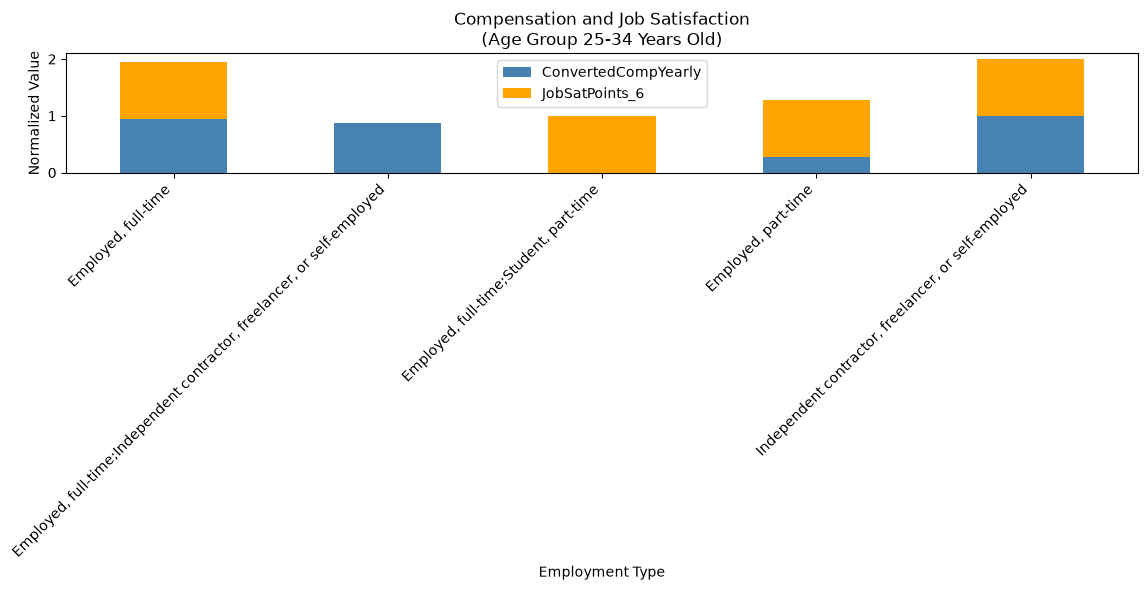

In [9]:
# Filter to respondents aged 25-34
plot_df = df[
    df["Age"] == "25-34 years old"
][["Employment", "ConvertedCompYearly", "JobSatPoints_6"]].copy()

# Convert columns to numeric
plot_df["ConvertedCompYearly"] = pd.to_numeric(
    plot_df["ConvertedCompYearly"], errors="coerce"
)

plot_df["JobSatPoints_6"] = pd.to_numeric(
    plot_df["JobSatPoints_6"], errors="coerce"
)

# Remove missing values
plot_df = plot_df.dropna(
    subset=["Employment", "ConvertedCompYearly", "JobSatPoints_6"]
)

# Remove compensation outliers using IQR
Q1 = plot_df["ConvertedCompYearly"].quantile(0.25)
Q3 = plot_df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

plot_df = plot_df[
    (plot_df["ConvertedCompYearly"] >= Q1 - 1.5 * IQR) &
    (plot_df["ConvertedCompYearly"] <= Q3 + 1.5 * IQR)
]

# Top 5 Employment categories
top_employment = (
    plot_df["Employment"]
    .value_counts()
    .head(5)
    .index
)

plot_df = plot_df[
    plot_df["Employment"].isin(top_employment)
]

# Aggregate by Employment
summary = (
    plot_df.groupby("Employment")
    .agg({
        "ConvertedCompYearly": "median",
        "JobSatPoints_6": "median"
    })
)

# Normalize manually (0-1 scale)
summary["Comp_Norm"] = (
    (summary["ConvertedCompYearly"] - summary["ConvertedCompYearly"].min()) /
    (summary["ConvertedCompYearly"].max() - summary["ConvertedCompYearly"].min())
)

summary["JobSat_Norm"] = (
    (summary["JobSatPoints_6"] - summary["JobSatPoints_6"].min()) /
    (summary["JobSatPoints_6"].max() - summary["JobSatPoints_6"].min())
)

# Stacked bar chart
summary[["Comp_Norm", "JobSat_Norm"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["steelblue", "orange"]
)

plt.title(
    "Compensation and Job Satisfaction\n(Age Group 25-34 Years Old)"
)
plt.xlabel("Employment Type")
plt.ylabel("Normalized Value")
plt.legend(["ConvertedCompYearly", "JobSatPoints_6"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


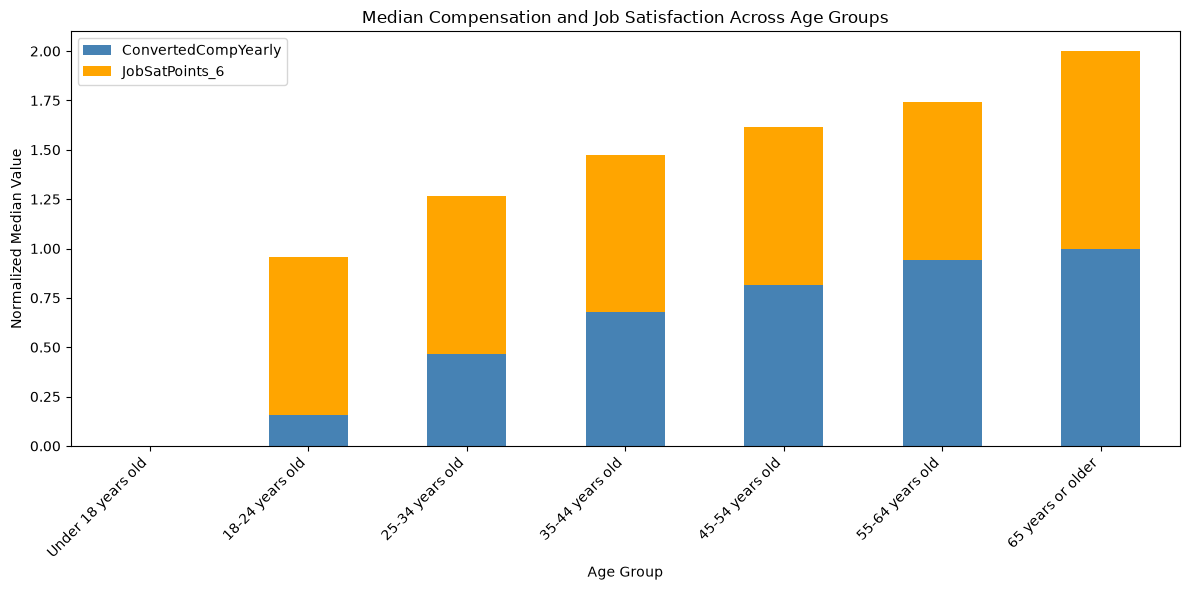

In [10]:
# Create working dataframe
plot_df = df[["Age", "ConvertedCompYearly", "JobSatPoints_6"]].copy()

# Convert columns to numeric
plot_df["ConvertedCompYearly"] = pd.to_numeric(
plot_df["ConvertedCompYearly"], errors="coerce"
)

plot_df["JobSatPoints_6"] = pd.to_numeric(
plot_df["JobSatPoints_6"], errors="coerce"
)

# Remove missing values
plot_df = plot_df.dropna(
subset=["Age", "ConvertedCompYearly", "JobSatPoints_6"]
)

# Remove compensation outliers using IQR
Q1 = plot_df["ConvertedCompYearly"].quantile(0.25)
Q3 = plot_df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

plot_df = plot_df[
    (plot_df["ConvertedCompYearly"] >= Q1 - 1.5 * IQR) &
    (plot_df["ConvertedCompYearly"] <= Q3 + 1.5 * IQR)
]

# Calculate median values by age group
summary = (
    plot_df.groupby("Age")
    .agg({
        "ConvertedCompYearly": "median",
        "JobSatPoints_6": "median"
    })
)

# Order age groups
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

summary = summary.reindex(age_order)

# Normalize each metric to 0-1 scale
summary["Comp_Norm"] = (
    (summary["ConvertedCompYearly"] - summary["ConvertedCompYearly"].min()) /
    (summary["ConvertedCompYearly"].max() - summary["ConvertedCompYearly"].min())
)

summary["JobSat_Norm"] = (
(summary["JobSatPoints_6"] - summary["JobSatPoints_6"].min()) /
(summary["JobSatPoints_6"].max() - summary["JobSatPoints_6"].min())
)

# Create stacked chart
summary[["Comp_Norm", "JobSat_Norm"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["steelblue", "orange"]
)

plt.title("Median Compensation and Job Satisfaction Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Normalized Median Value")
plt.legend(["ConvertedCompYearly", "JobSatPoints_6"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


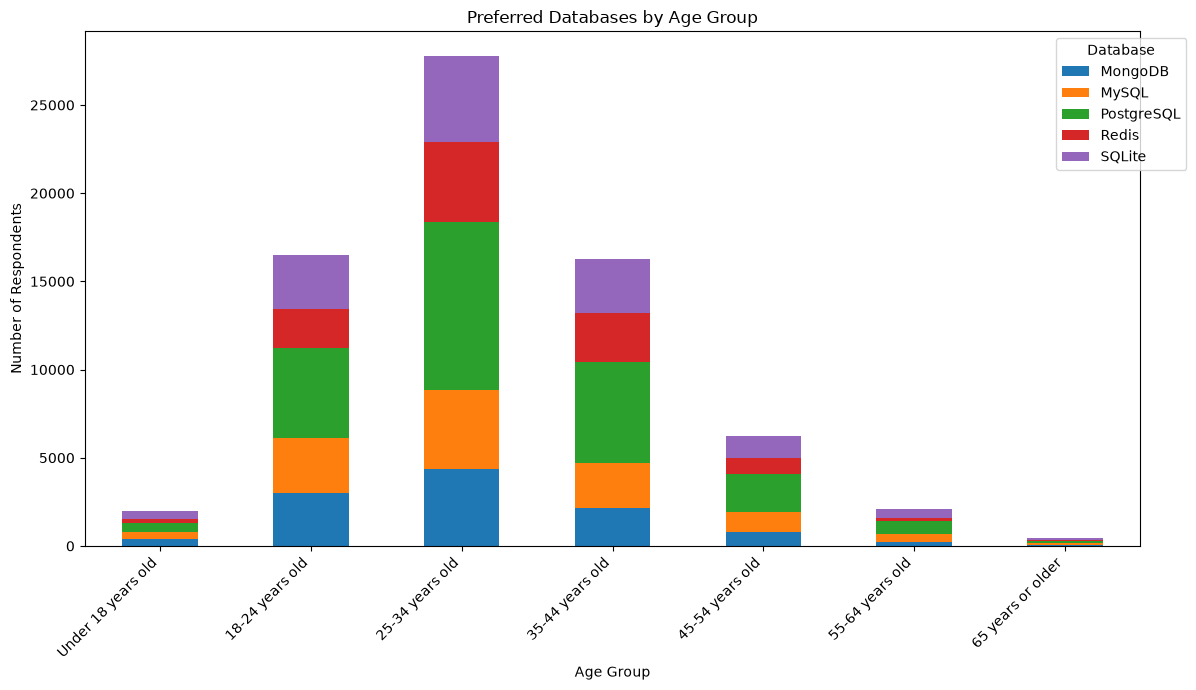

In [14]:
# Remove duplicate columns if any
df = df.loc[:, ~df.columns.duplicated()]

# Create working dataframe
plot_df = df[["Age", "DatabaseWantToWorkWith"]].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Split databases
plot_df = plot_df.assign(
    Database=plot_df["DatabaseWantToWorkWith"].str.split(";")
).explode("Database")

plot_df["Database"] = plot_df["Database"].str.strip()

# Top 5 databases
top_databases = (
    plot_df["Database"]
    .value_counts()
    .head(5)
    .index
)

plot_df = plot_df[
    plot_df["Database"].isin(top_databases)
]

# Frequency table
database_age = (
    plot_df
    .groupby(["Age", "Database"])
    .size()
    .unstack(fill_value=0)
)

# Order age groups
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

database_age = database_age.reindex(age_order)

# Stacked chart
database_age.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Preferred Databases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.legend(title="Database", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


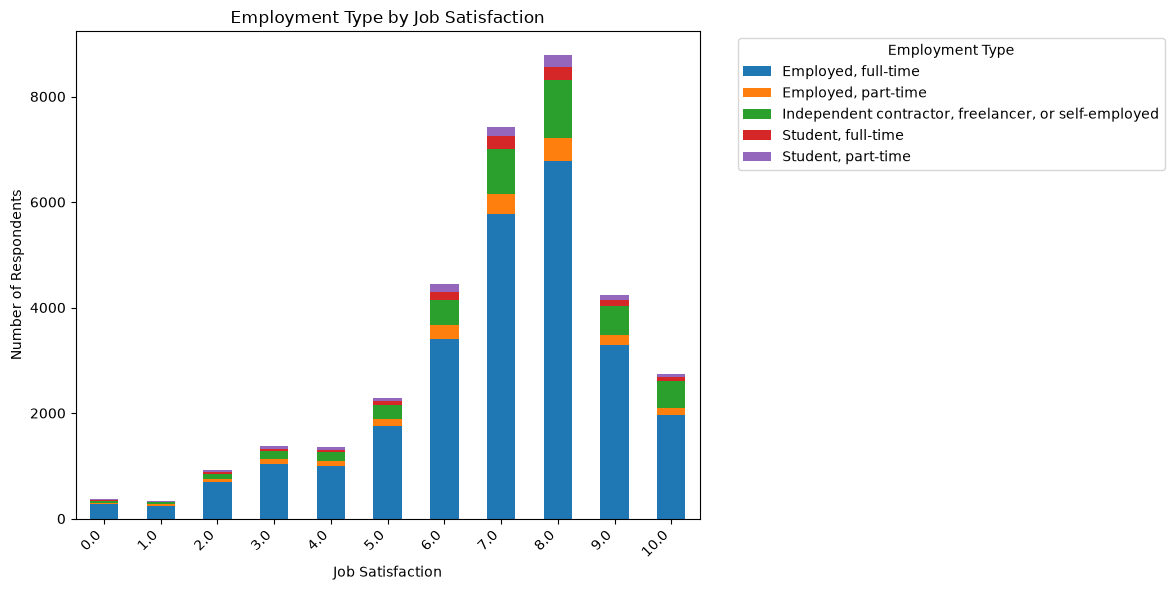

In [16]:
# Create working dataframe
plot_df = df[["Employment", "JobSat"]].copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Employment", "JobSat"])

# Split multiple employment types into separate rows
plot_df = plot_df.assign(
    EmploymentType=plot_df["Employment"].str.split(";")
).explode("EmploymentType")

# Clean whitespace
plot_df["EmploymentType"] = plot_df["EmploymentType"].str.strip()

# Top 5 employment types
top_employment = (
    plot_df["EmploymentType"]
    .value_counts()
    .head(5)
    .index
)

plot_df = plot_df[
    plot_df["EmploymentType"].isin(top_employment)
]

# Create frequency table
stacked_data = (
    plot_df.groupby(["JobSat", "EmploymentType"])
    .size()
    .unstack(fill_value=0)
)

# Plot stacked chart
stacked_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Employment Type by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Respondents")
plt.legend(
    title="Employment Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


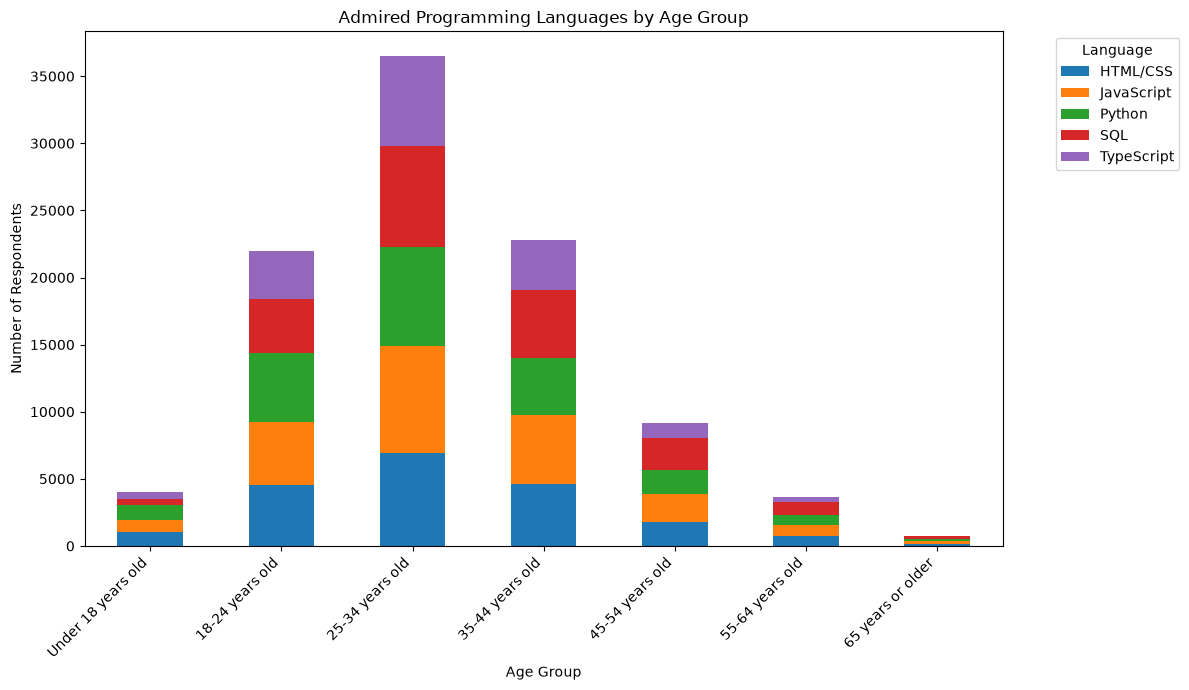

In [17]:
# Create working dataframe
plot_df = df[["Age", "LanguageAdmired"]].copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Age", "LanguageAdmired"])

# Split multiple languages into separate rows
plot_df = plot_df.assign(
    Language=plot_df["LanguageAdmired"].str.split(";")
).explode("Language")

# Remove whitespace
plot_df["Language"] = plot_df["Language"].str.strip()

# Keep top 5 admired languages
top_languages = (
    plot_df["Language"]
    .value_counts()
    .head(5)
    .index
)

plot_df = plot_df[
    plot_df["Language"].isin(top_languages)
]

# Create Age vs Language frequency table
language_age = (
    plot_df.groupby(["Age", "Language"])
    .size()
    .unstack(fill_value=0)
)

# Order age groups
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Keep only age groups that exist in the data
language_age = language_age.reindex(
    [age for age in age_order if age in language_age.index]
)

# Plot stacked chart
language_age.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Admired Programming Languages by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.legend(
    title="Language",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


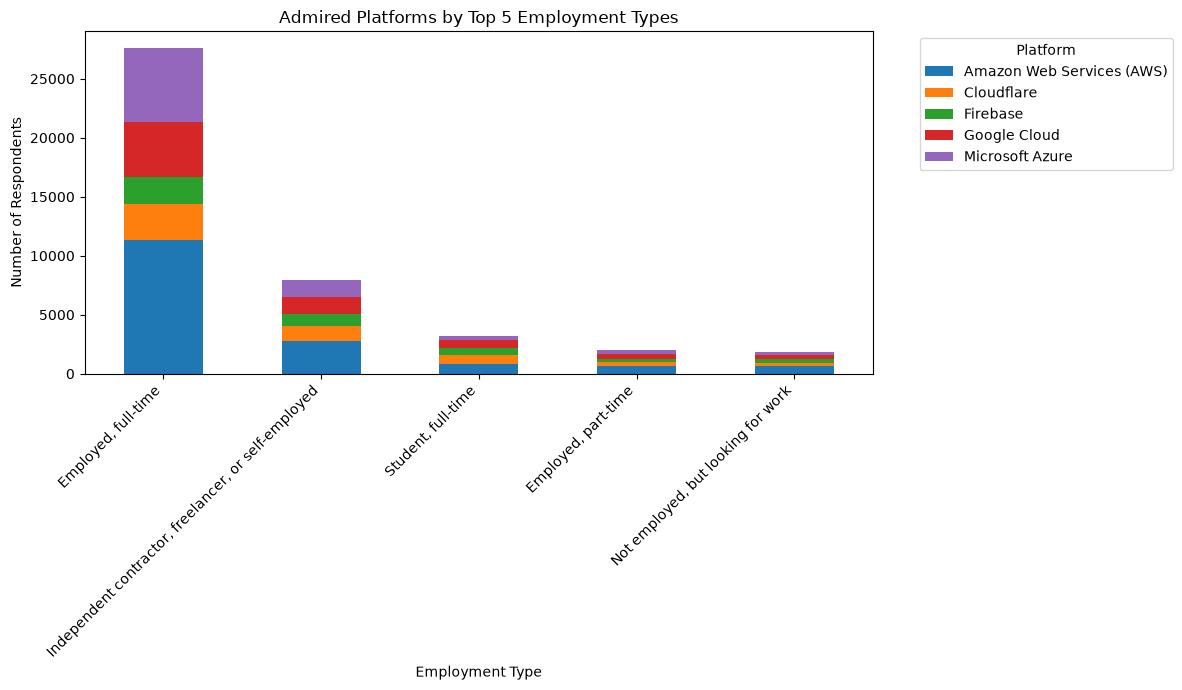

In [19]:
# Create working dataframe
plot_df = df[["Employment", "PlatformAdmired"]].copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Employment", "PlatformAdmired"])

# Split employment types into separate rows
plot_df = plot_df.assign(
    EmploymentType=plot_df["Employment"].str.split(";")
).explode("EmploymentType")

plot_df["EmploymentType"] = plot_df["EmploymentType"].str.strip()

# Split admired platforms into separate rows
plot_df = plot_df.assign(
    Platform=plot_df["PlatformAdmired"].str.split(";")
).explode("Platform")

plot_df["Platform"] = plot_df["Platform"].str.strip()

# Keep only the top 5 employment types
top_employment = (
    plot_df["EmploymentType"]
    .value_counts()
    .head(5)
    .index
)

plot_df = plot_df[
    plot_df["EmploymentType"].isin(top_employment)
]

# Keep only the top 5 admired platforms
top_platforms = (
    plot_df["Platform"]
    .value_counts()
    .head(5)
    .index
)

plot_df = plot_df[
    plot_df["Platform"].isin(top_platforms)
]

# Create frequency table
platform_employment = (
    plot_df
    .groupby(["EmploymentType", "Platform"])
    .size()
    .unstack(fill_value=0)
)

# Sort employment types by frequency
employment_order = (
    plot_df["EmploymentType"]
    .value_counts()
    .loc[top_employment]
    .index
)

platform_employment = platform_employment.reindex(employment_order)

# Create stacked chart
platform_employment.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Admired Platforms by Top 5 Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("Number of Respondents")
plt.legend(
    title="Platform",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
